# Iris Dataset — Data Exploration

Before training any model I want to understand what the data looks like.
This notebook explores the Iris dataset: basic stats, distributions,
relationships between features, and how separable the 3 species are.

**Dataset**: Iris (Fisher, 1936) — 150 flowers, 4 measurements, 3 species  
**Practice 2** — Software Development Oriented to Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load and inspect

In [2]:
iris = load_iris()

# build a DataFrame from the raw numpy arrays
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species_id"] = iris.target
df["species"] = df["species_id"].map(
    {i: n for i, n in enumerate(iris.target_names)}
)

print(f"{len(df)} samples, {len(iris.feature_names)} features, {len(iris.target_names)} classes")
df.head(10)

150 samples, 4 features, 3 classes


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


In [3]:
# summary stats for the numeric features
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# class balance — how many samples per species?
print(df["species"].value_counts())
# 50 each — perfectly balanced, no need for oversampling

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [5]:
# any missing values?
print(df.isnull().sum())
# all zeros — nothing missing

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_id           0
species              0
dtype: int64


## 2. Feature distributions (histograms)

For each of the 4 features I plot a histogram colored by species.
This shows whether a feature separates species well.

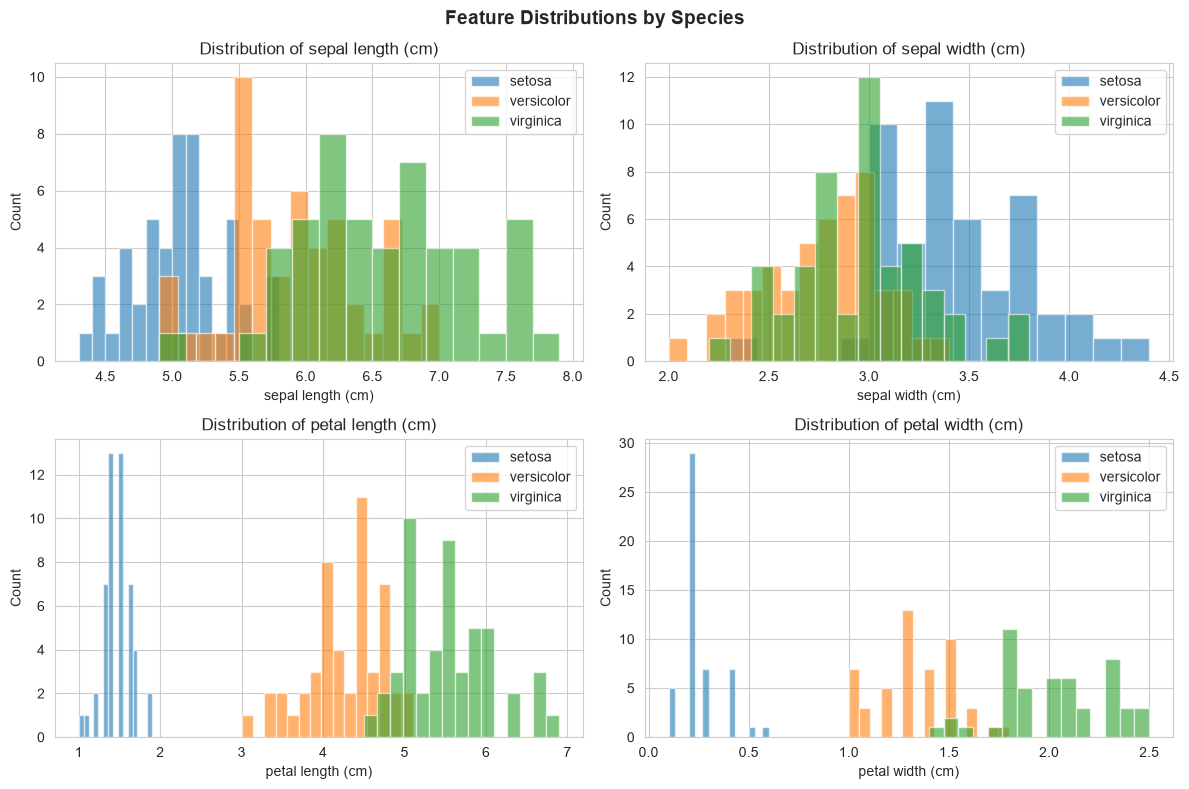

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), iris.feature_names):
    for sp in iris.target_names:
        subset = df[df["species"] == sp]
        ax.hist(subset[feature], bins=15, alpha=0.6, label=sp)
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {feature}")
    ax.legend()

fig.suptitle("Feature Distributions by Species", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/histograms.png", dpi=150)
plt.show()

Petal length and petal width separate species much better than
sepal measurements. Setosa sits clearly on its own; versicolor
and virginica overlap a bit.

## 3. Box plots by species

Box plots show median, quartiles, and outliers at a glance.

C:\Users\BFC-G-13\AppData\Local\Temp\ipykernel_23144\1017220131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feature, palette="Set2", ax=ax)
C:\Users\BFC-G-13\AppData\Local\Temp\ipykernel_23144\1017220131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feature, palette="Set2", ax=ax)
C:\Users\BFC-G-13\AppData\Local\Temp\ipykernel_23144\1017220131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feature, palette="Set2", ax=ax)
C:\Users\BFC-G-13\AppData\Local

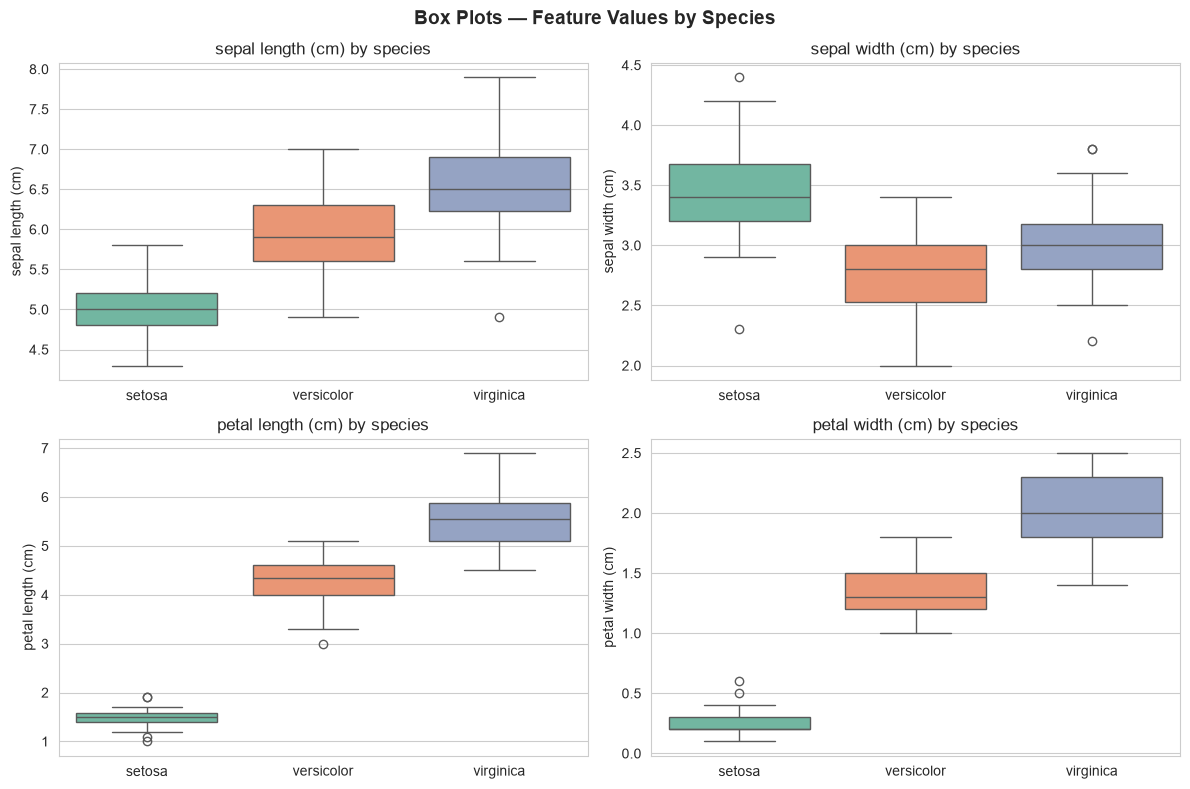

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), iris.feature_names):
    sns.boxplot(data=df, x="species", y=feature, palette="Set2", ax=ax)
    ax.set_title(f"{feature} by species")
    ax.set_xlabel("")

fig.suptitle("Box Plots — Feature Values by Species", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/boxplots.png", dpi=150)
plt.show()

Setosa petals are tiny compared to the other two. Virginica
is generally the largest. A few outliers but nothing alarming.

## 4. Scatter plots

The petal length vs petal width scatter is the best 2D view
of how the classes separate.

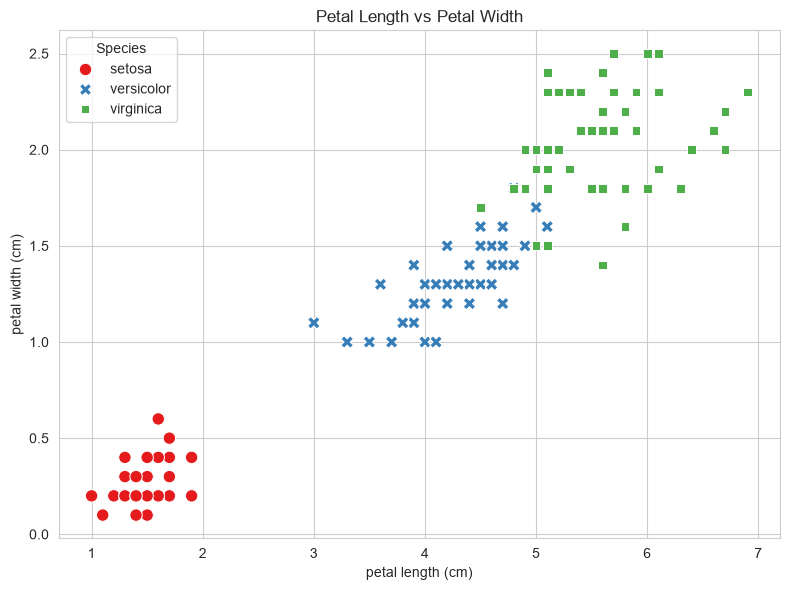

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    style="species",
    s=80,
    palette="Set1",
    ax=ax,
)
ax.set_title("Petal Length vs Petal Width")
ax.legend(title="Species")
plt.tight_layout()
plt.savefig("../reports/figures/scatter_petal.png", dpi=150)
plt.show()

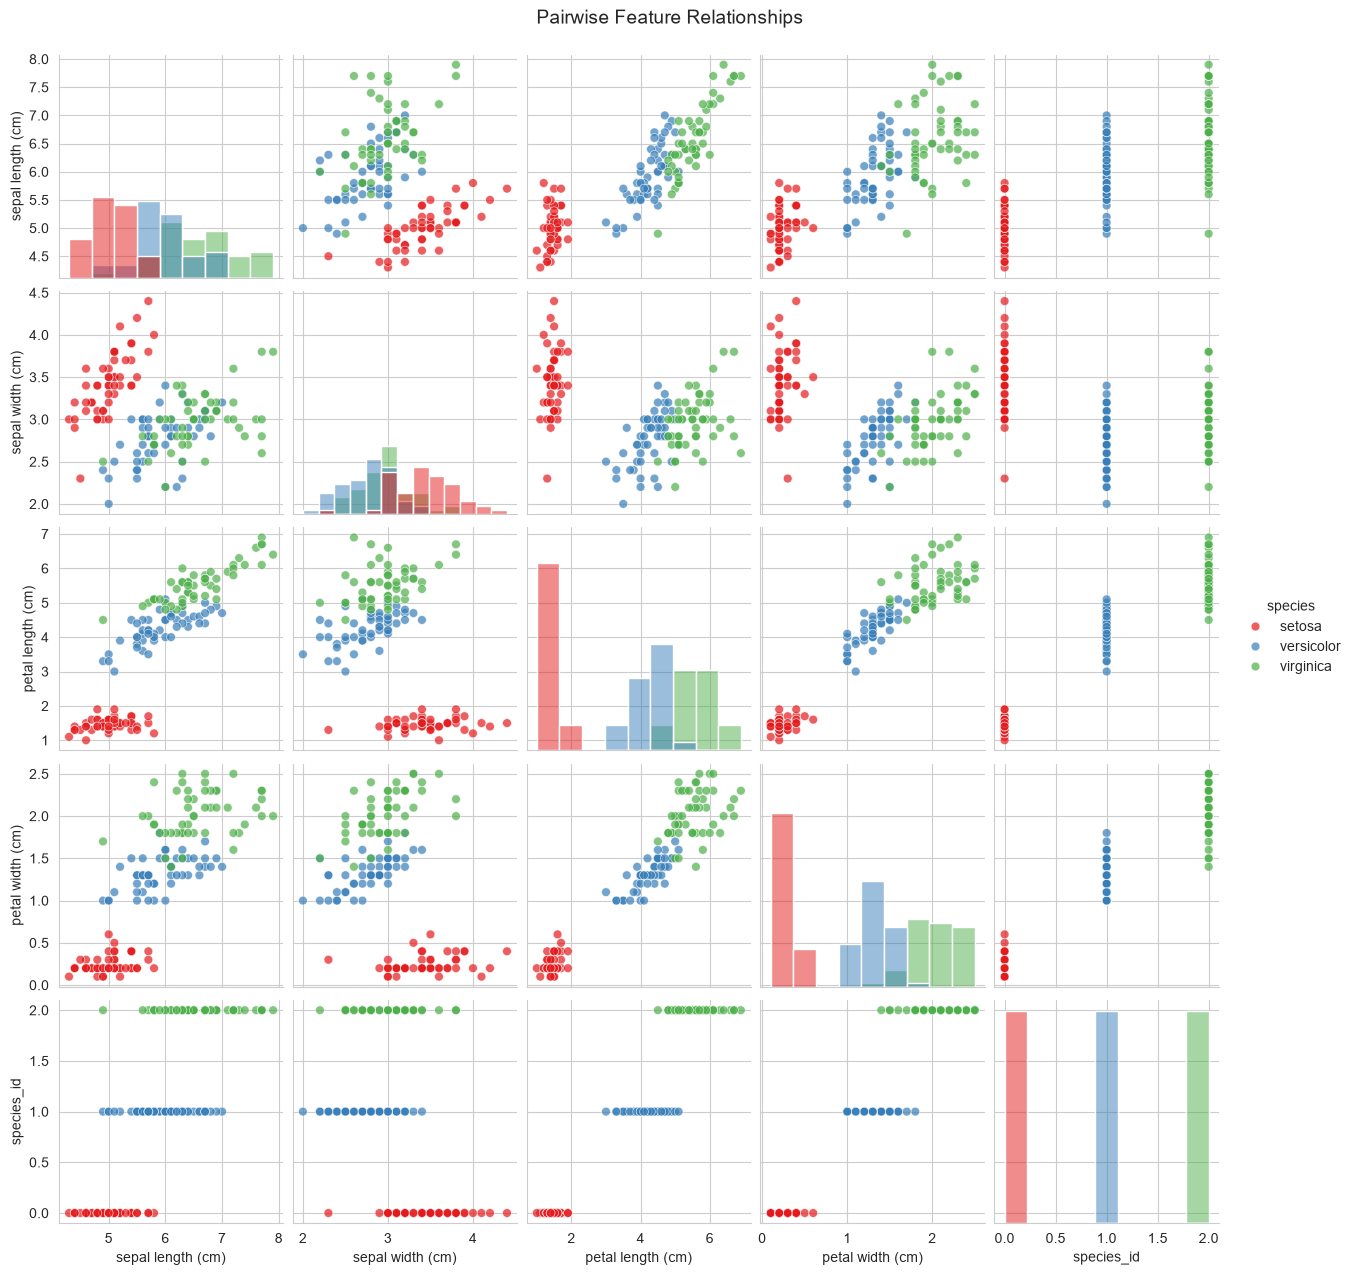

In [9]:
# pair plot — scatter for every pair of features, histograms on diagonal
g = sns.pairplot(df, hue="species", palette="Set1",
                 diag_kind="hist",
                 plot_kws={"alpha": 0.7, "s": 40})
g.figure.suptitle("Pairwise Feature Relationships", y=1.02, fontsize=14)
plt.savefig("../reports/figures/pairplot.png", dpi=150, bbox_inches="tight")
plt.show()

Setosa forms a tight cluster everywhere. Versicolor and virginica
overlap in sepal features but are more separable in petal features.

## 5. Correlation heatmap

Correlation ranges from -1 (inversely related) to +1 (move together).
Values near 0 mean no linear relationship.

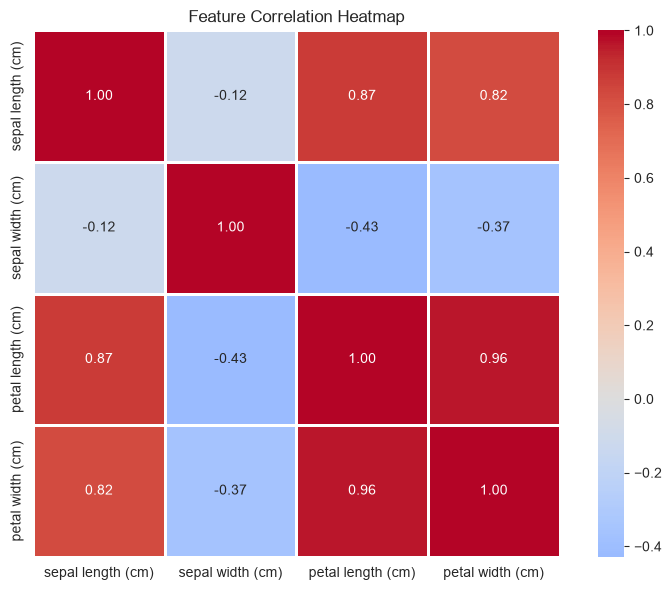

In [10]:
corr = df[list(iris.feature_names)].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=1, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_heatmap.png", dpi=150)
plt.show()

Petal length and petal width correlate strongly (0.96) — bigger
petals grow proportionally. Sepal width is the odd one out with
weak/negative correlations to the rest.

## Summary

1. **Balanced** dataset: 50 samples per class, no missing values.
2. **Petal features** are the best separators.
3. **Setosa** is easy — well separated from the others.
4. **Versicolor / virginica** overlap in some measurements — this is where errors will happen.
5. **Petal length ↔ petal width** correlation is 0.96.

Even a simple linear model like Logistic Regression should handle this well.